# The Auto-Regressive Integrated Moving Average (ARIMA) Model
The ARIMA model extends ARMA to handle non-stationary time series by differencing.

An ARIMA model predicts future values based on past values and past forecast errors. 

## **a). Define the ARIMA(p,d,q) model. Explain the meaning of p, d, and q.**

ARIMA combines autoregression and a moving average model with differencing to handle non-stationary data. The model can be expressed as:
$$Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + ... + \phi_p Y_{t-p} + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + ... + \theta_q \epsilon_{t-q} + \epsilon_t$$

where:
- $Y_t$ is the value at time t
- $c$ is a constant
- $\phi_i$ are the coefficients for the autoregressive terms
- $\theta_j$ are the coefficients for the moving average terms.
- $\epsilon_t$ is the error term at time t.

The parameters are defined as follows:

- **p**: The number of autoregressive terms. This indicates how many past values are used to predict the current value.
- **d**: The degree of differencing. This indicates how many times the data needs to be differenced to achieve stationarity.
- **q**: The number of moving average terms. This indicates how many past forecast errors are used to predict the current value.

## **b). Explain why differencing is used and how it helps achieve stationarity.**

Differencing is a technique used to transform a non-stationary time series into a stationary one by removing trends and seasonality. A time series is considered stationary if its statistical properties, such as mean and variance, are constant over time. Non-stationary data can lead to unreliable and spurious results when modeling.

By differencing the data, we can eliminate trends and seasonality, making the series more stable and easier to model. For example, if a time series has a linear trend, taking the first difference $ \Delta Y_t = Y_t - Y_{t-1} $ can help remove that trend. If the series still exhibits non-stationarity after the first differencing, further differencing may be necessary.

## **c). Discuss the ACF and PACF patterns before and after differencing and how they guide model identification**

**Before Differencing (Non-Stationary)**
- **ACF**: Decays very slowly. This proves the data has a trend and relies heavily on its distant past.
- **PACF**: Has one massive spike at lag 1, then drops instantly.

**After Differencing (Stationary)**
- **ACF & PACF**: Both drop toward zero rapidly because the trend is removed.
- The remaining significant spikes that break outside the shaded confidence band are now your actual AR ($p$) and MA ($q$) signatures.

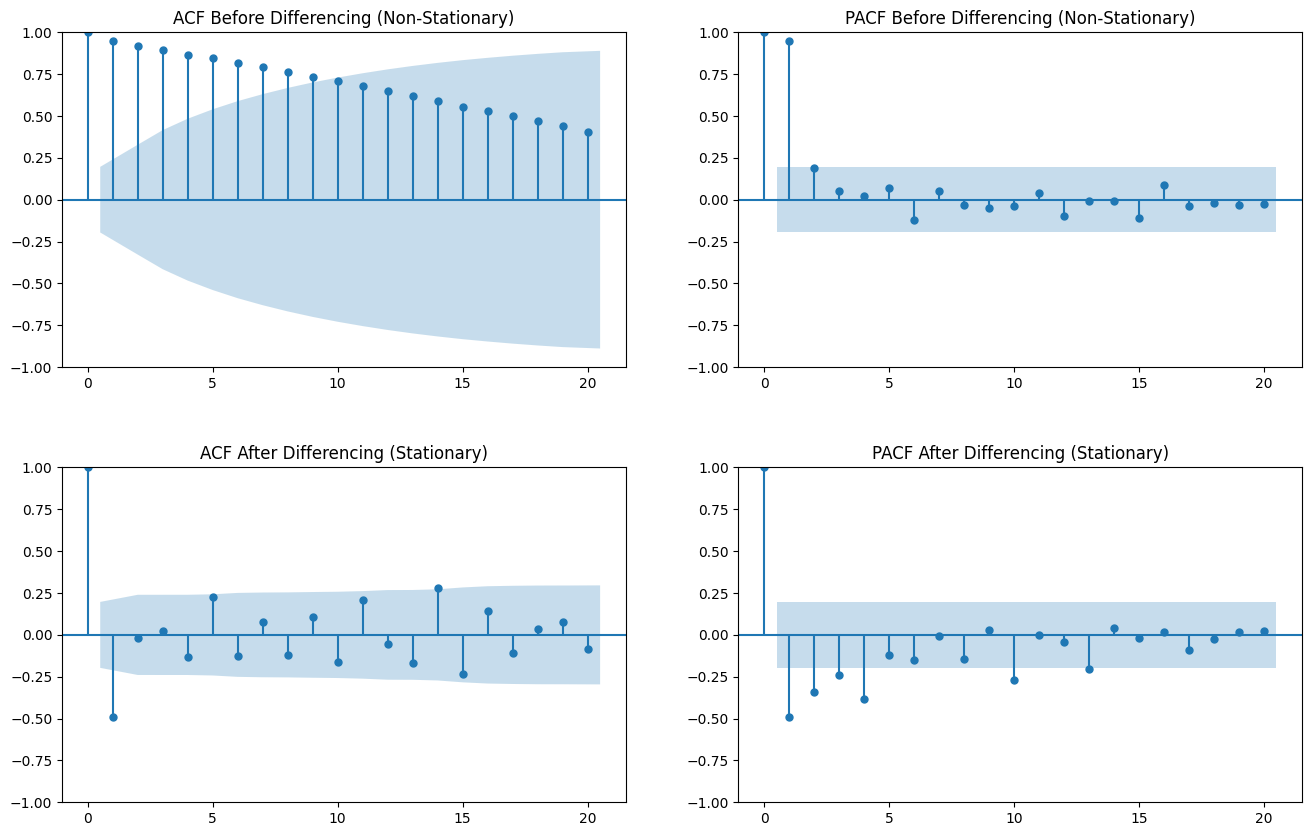

In [15]:
# type: ignore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Recreate the dataset
np.random.seed(42)
time = np.arange(100)
data = 50 + (2 * time) + np.random.normal(0, 10, 100) 
df = pd.DataFrame({'Value': data})

# 2. Difference the data
df['Diff_1'] = df['Value'].diff().dropna()

# 3. Set up the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.subplots_adjust(hspace=0.3)

# --- Top Row: Before Differencing (Non-Stationary) ---
plot_acf(df['Value'], lags=20, ax=axes[0, 0])
axes[0, 0].set_title('ACF Before Differencing (Non-Stationary)')

plot_pacf(df['Value'], lags=20, ax=axes[0, 1], method='ywm')
axes[0, 1].set_title('PACF Before Differencing (Non-Stationary)')

# --- Bottom Row: After Differencing (Stationary) ---
plot_acf(df['Diff_1'].dropna(), lags=20, ax=axes[1, 0])
axes[1, 0].set_title('ACF After Differencing (Stationary)')

plot_pacf(df['Diff_1'].dropna(), lags=20, ax=axes[1, 1], method='ywm')
axes[1, 1].set_title('PACF After Differencing (Stationary)')

plt.show()

Generating Data

In [ ]:
# type: ignore
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

# Create a dataset with a clear upward trend
np.random.seed(42)
time = np.arange(100)
# Base value 50 + trend of 2 per step + random noise
data = 50 + (2 * time) + np.random.normal(0, 10, 100) 
df = pd.DataFrame({'Value': data})

## **d). Describe practical steps to fit an ARIMA model:**

### *i. Determine the order of differencing (d) needed.*

- Plot the time series. If it shows an upward or downward trend, it is non-stationary.
- Run an Augmented Dickey-Fuller (ADF) test. If the p-value is greater than 0.05, the data is non-stationary.
- Apply first-order differencing $d=1$. Calculate the difference between consecutive observations: $y'_t = y_t - y_{t-1}$.
- Run the ADF test on this newly differenced data. If the p-value drops below 0.05, it is now stationary. Your $d$ is 1.
- If it is still non-stationary, difference it a second time ($d=2$). It is extremely rare to use $d > 2$. If $d=2$ fails, you likely need a log transformation before differencing.

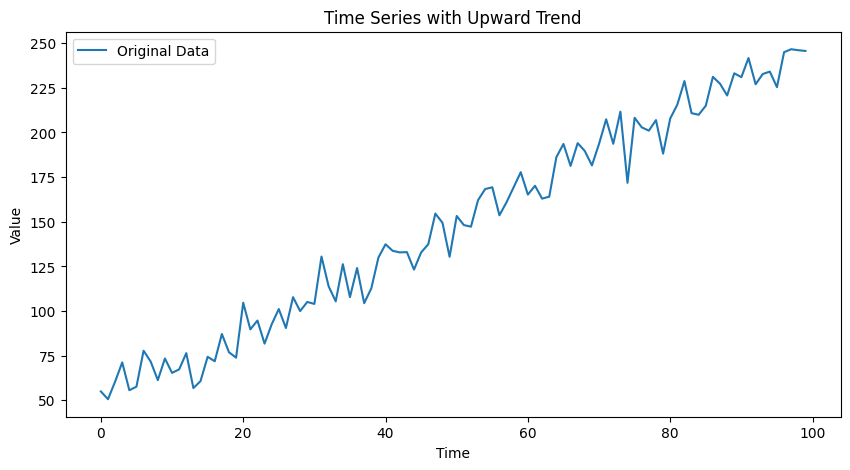

In [ ]:
# Plot the time series
# type: ignore
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(df['Value'], label='Original Data')
plt.title('Time Series with Upward Trend')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()


In [18]:
# Run ADF Test on the raw data (Testing d=0)
print("--- Testing Raw Data (d=0) ---")
result_raw = adfuller(df['Value'])
print(f"ADF Statistic: {result_raw[0]:.4f}")
print(f"p-value: {result_raw[1]:.4f}\n")


--- Testing Raw Data (d=0) ---
ADF Statistic: 0.0963
p-value: 0.9658



- $H_0$: The time series has a unit root (non-stationary).
- $H_1$: The time series does not have a unit root (stationary).

Since the p-value is greater than 0.05, we fail to reject the null hypothesis, indicating that the original series is non-stationary. We will apply first-order differencing ($d=1$) to attempt to achieve stationarity.

In [19]:

# Apply first-order differencing (d=1)
df['Diff_1'] = df['Value'].diff().dropna()

# 4. Run ADF Test on the differenced data (Testing d=1)
print("--- Testing Differenced Data (d=1) ---")
result_diff = adfuller(df['Diff_1'].dropna())
print(f"ADF Statistic: {result_diff[0]:.4f}")
print(f"p-value: {result_diff[1]:.4f}")

--- Testing Differenced Data (d=1) ---
ADF Statistic: -5.1946
p-value: 0.0000


After the first-order differencing, the p-value dropped to 0.000, which is less than 0.05, allowing us to reject the null hypothesis. This indicates that the differenced series is now stationary, confirming that $d=1$ is appropriate for our ARIMA model.

### *ii. Identify AR and MA orders (p and q) using ACF/PACF.*
Generate the ACF and PACF plots strictly on the differenced (stationary) data.
- To find $p$: Count the number of significant spikes on the PACF plot before it sharply drops inside the blue confidence band. If the ACF plot decays gradually, use this number for $p$ and set $q=0$.
- To find $q$: Count the number of significant spikes on the ACF plot before it sharply drops inside the confidence band. If the PACF plot decays gradually, use this number for $q$ and set $p=0$.
- If both decay gradually: The visual rules fail. Set $p=1$ and $q=1$ as a starting point and move to step iv.



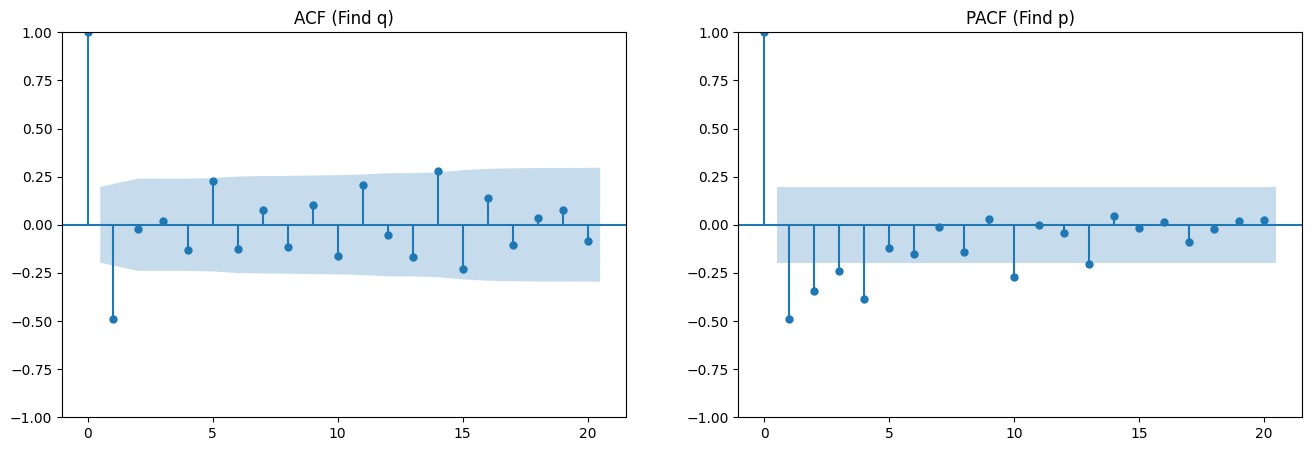

In [ ]:
# type: ignore
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Drop the NaN value created by the differencing step
diff_data = df['Diff_1'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot ACF to identify MA order (q)
plot_acf(diff_data, lags=20, ax=axes[0])
axes[0].set_title('ACF (Find q)')

# Plot PACF to identify AR order (p)
plot_pacf(diff_data, lags=20, ax=axes[1], method='ywm')
axes[1].set_title('PACF (Find p)')

plt.show()

ACF: The correlation cuts off sharply after lag 1. The spike at lag 1 is strongly negative and clearly outside the blue confidence band, while lag 2 instantly drops inside the band. This indicates a Moving Average order of q = 1.

PACF: The correlation tails off gradually. You can see a decaying pattern of multiple negative spikes at lags 1, 2, 3, and 4 slowly shrinking toward the center band. This confirms there is no Autoregressive component. This means p = 0.

**Conclusion**: This data displays a perfect MA(1) signature. Assuming this data was differenced once to achieve stationarity, your final parameters for the model are ARIMA(0, 1, 1).

### *iii. Fit the ARIMA model using statistical software.*



In [ ]:
# type: ignore
from statsmodels.tsa.arima.model import ARIMA

# p=0, d=1, q=1
model = ARIMA(df['Value'], order=(0, 1, 1))
fitted_model = model.fit()

# View the mathematical summary and test statistics
print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                  100
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -380.217
Date:                Fri, 27 Mar 2026   AIC                            764.433
Time:                        12:45:00   BIC                            769.624
Sample:                             0   HQIC                           766.533
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5392      0.095     -5.675      0.000      -0.725      -0.353
sigma2       126.4419     18.481      6.842      0.000      90.220     162.663
Ljung-Box (L1) (Q):                   5.55   Jarque-

**The Coefficients**
- ma.L1 (Moving Average Lag 1): The calculated weight is -0.5392.
- P>|z| (P-value): The p-value for ma.L1 is 0.000. Because this is less than 0.05, the MA term is statistically significant. It actively contributes to the forecast and belongs in the equation.
- sigma2: This is the estimated variance of the model's errors (126.44).

**Diagnostic Tests (Checking Assumptions)**

The model must pass three statistical tests to be considered valid for forecasting. The null hypothesis for these tests assumes your model is perfect (residuals are normal, random white noise).
- Ljung-Box Prob(Q) [FAILED]: The score is 0.02. Because this is below 0.05, we reject the null hypothesis. This means your model left behind mathematical patterns in the data. The errors are not random white noise.
- Heteroskedasticity Prob(H) [PASSED]: The score is 0.69. Because this is above 0.05, the variance of your errors is constant over time.
- Jarque-Bera Prob(JB) [PASSED]: The score is 0.59. Because this is above 0.05, your forecast errors are normally distributed (they form a standard bell curve).

**Conclusion:**
Because the model failed the Ljung-Box test, ARIMA(0,1,1) is incomplete. It missed a pattern. You need to fit additional models, such as ARIMA(1,1,1) or ARIMA(0,1,2), to capture the remaining autocorrelation.

A failed Ljung-Box test means your model left usable information in the forecast errors. The errors are not random white noise; they still contain a mathematical pattern.
You must change your model's p or q parameters to capture this leftover pattern.

To achieve this, you must:
- Plot the ACF and PACF of the models residuals to identify the leftover pattern.
- Adjust the p and q parameters to capture this pattern.
    - If the residual ACF has a significant spike outside the blue band (e.g., at lag 2), you need to increase your $q$ parameter. Upgrade your model to ARIMA(0, 1, 2).
    - If the residual PACF has a significant spike, you need to add an AR term. Upgrade your model to ARIMA(1, 1, 1).
- Check for seasonalityL If you see a massive spike in the residual ACF far down the line, such as exactly at lag 12 (monthly data) or lag 7 (daily data), you have a repeating seasonal pattern. Standard ARIMA cannot fix this. You must switch to a SARIMA model (Seasonal ARIMA) to handle the cyclic behavior.
- Refit and retest

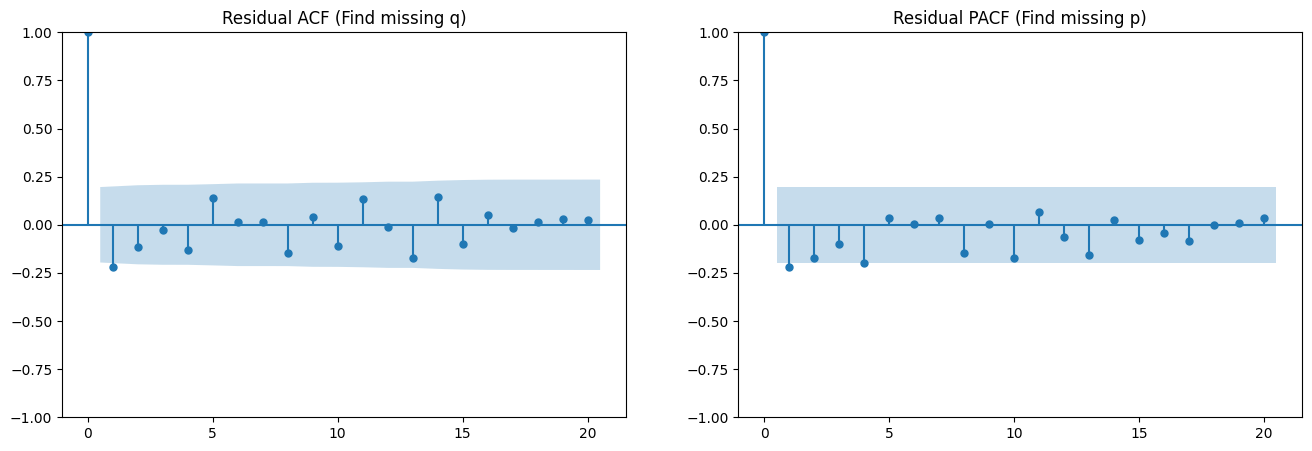

In [ ]:
# type: ignore
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Extract the leftover errors from your fitted model
residuals = fitted_model.resid

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(residuals, lags=20, ax=axes[0])
axes[0].set_title('Residual ACF (Find missing q)')

plot_pacf(residuals, lags=20, ax=axes[1], method='ywm')
axes[1].set_title('Residual PACF (Find missing p)')

plt.show()

In [23]:
# Fit both candidate models and print their summaries
orders = [(0, 1, 2), (1, 1, 1)]
fitted_models = {}

for order in orders:
    model = ARIMA(df['Value'], order=order)
    fitted_models[order] = model.fit()
    print(f"\n--- ARIMA{order} ---")
    print(fitted_models[order].summary())



--- ARIMA(0, 1, 2) ---
                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                  100
Model:                 ARIMA(0, 1, 2)   Log Likelihood                -379.707
Date:                Fri, 27 Mar 2026   AIC                            765.415
Time:                        12:45:01   BIC                            773.200
Sample:                             0   HQIC                           768.565
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6220      0.105     -5.942      0.000      -0.827      -0.417
ma.L2          0.0957      0.107      0.890      0.373      -0.115       0.306
sigma2       125.0684     18

- ARIMA(0, 1, 2) scored 0.14. (Pass)
- ARIMA(1, 1, 1) scored 0.09. (Pass)

Since the AIC values for both new models are higher than the original ARIMA(0, 1, 1) model (which had an AIC of 764.433), neither of the new models improved the fit. The original ARIMA(0, 1, 1) model remains the best choice based on AIC.

### *iv. Fit two more models and compare them based on AIC/BIC values*

- AIC: AIC (Akaike Information Criterion) estimates the relative quality of statistical models for a given set of data. It deals with the trade-off between the goodness of fit of the model and the complexity of the model.Why BIC matters: 
- BIC (Bayesian Information Criterion) does the same thing but penalizes complex models (models with more $p$ and $q$ parameters) much harder than AIC does.Tie-breakers: 
- If Model A has a lower AIC but Model B has a lower BIC, rely on AIC if your primary goal is accurate future forecasting. Rely on BIC if your primary goal is understanding the true underlying structure of the historical data

**Interpretation of AIC values:**
- Original ARIMA(0, 1, 1) AIC: 764.433
- New ARIMA(0, 1, 2) AIC: 765.415
- New ARIMA(1, 1, 1) AIC: 765.704
The AIC went up. The metric penalized you for adding extra complexity without improving the model's accuracy.

## **e). Comment on assumptions, limitations, and scenarios where ARIMA is preferred over ARMA.**

### Assumptions:
The residuals of the fitted model must be white noise (independent, identically distributed normal variables with a mean of zero). The relationships between current and past values are linear.

### Limitations:
- ARIMA models can be sensitive to outliers and may not perform well with non-linear relationships.
- ARIMA cannot handle volatility clustering (changing variance over time), which requires models like GARCH. 
- It is poor at long-term forecasting because predictions quickly converge to the series mean or trend line. 
- It cannot model non-linear relationships.

### Scenarios where ARIMA is preferred:
- When the time series data is non-stationary and can be made stationary through differencing.
- When the data exhibits trends or seasonality that can be removed through differencing.
- When the primary goal is short-term forecasting and the data does not exhibit complex patterns that require more advanced models.

ARIMA is strictly preferred over ARMA when the raw time series is non-stationary (e.g., it contains a trend).

## SARIMA (Seasonal ARIMA) Models
SARIMA extends ARIMA to handle seasonality in the data. It includes additional parameters to model seasonal autoregressive and moving average components, as well as seasonal differencing.

**When SARIMA is preferred over ARIMA:**
- When the data exhibits strong seasonal patterns that repeat at regular intervals (e.g., The Airline Passenger dataset. People fly more in the summer and less in the winter. A standard ARIMA model is completely blind to repeating 12-month cycles. Because it could not see the summer spikes coming, it likely drew a flat line through your test data, causing massive errors.).

SARIMA adds a second set of $(P, D, Q, s)$ parameters to handle the repeating loops. Because the data is monthly and repeats yearly, your season length ($s$) is 12. You apply a seasonal difference ($D=1$) which subtracts this month's data from the exact same month last year, achieving true stationarity.


--- ADF Test: Raw Log Data (Testing d=0) ---
p-value: 0.4966

--- ADF Test: First-Order Differencing (Testing d=1) ---
p-value: 0.0858

--- Standard Error Metrics ---
ARIMA Model -> RMSE: 96.33 | MAPE: 21.01%
Naive Model -> RMSE: 52.49 | MAPE: 10.26%


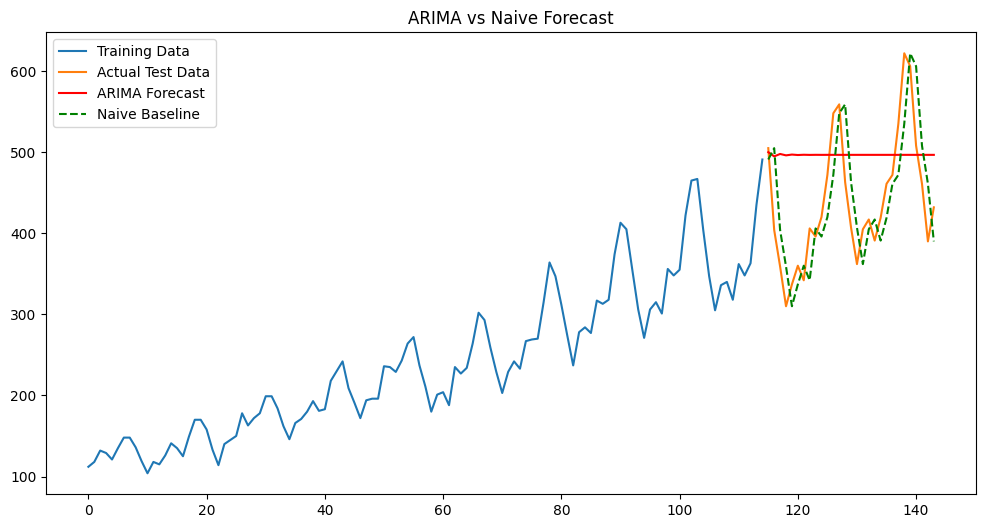

In [24]:
# type: ignore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import statsmodels.api as sm

# Monthly Airline Passengers)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, usecols=[1])
df.columns = ['Passengers']

# Stabilize variance with a log transformation before differencing
df['Log_Passengers'] = np.log(df['Passengers'])

# Split into Train/Test (80/20 Chronological)
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size].copy()
test = df.iloc[train_size:].copy()

# Check Stationarity & Transform
print("--- ADF Test: Raw Log Data (Testing d=0) ---")
print(f"p-value: {adfuller(train['Log_Passengers'])[1]:.4f}") # > 0.05, Non-stationary

train['Diff_1'] = train['Log_Passengers'].diff().dropna()

print("\n--- ADF Test: First-Order Differencing (Testing d=1) ---")
print(f"p-value: {adfuller(train['Diff_1'].dropna())[1]:.4f}") # < 0.05, Stationary. d=1.

# Identify AR and MA orders (Uncomment to view plots)
# plot_acf(train['Diff_1'].dropna(), lags=20)
# plot_pacf(train['Diff_1'].dropna(), lags=20)
# plt.show()
# Visuals show tails in both, suggesting a mixed model. We will use p=1, q=1.

# Fit the ARIMA Model
# Pass the un-differenced log data. The order=(1,1,1) handles differencing internally.
model = ARIMA(train['Log_Passengers'], order=(1, 1, 1))
fitted_model = model.fit()

# Forecast the Test Data
# The model outputs log values. Use np.exp() to convert back to actual passenger counts.
forecast_log = fitted_model.forecast(steps=len(test))
test['ARIMA_Forecast'] = np.exp(forecast_log.values)

# Create the Naive Baseline (Tomorrow's prediction = Today's actual value)
naive_forecast = [train['Passengers'].iloc[-1]] + list(test['Passengers'].iloc[:-1])
test['Naive_Forecast'] = naive_forecast

# Perform Standard Error Metrics
arima_rmse = np.sqrt(mean_squared_error(test['Passengers'], test['ARIMA_Forecast']))
arima_mape = mean_absolute_percentage_error(test['Passengers'], test['ARIMA_Forecast'])

naive_rmse = np.sqrt(mean_squared_error(test['Passengers'], test['Naive_Forecast']))
naive_mape = mean_absolute_percentage_error(test['Passengers'], test['Naive_Forecast'])

print("\n--- Standard Error Metrics ---")
print(f"ARIMA Model -> RMSE: {arima_rmse:.2f} | MAPE: {arima_mape:.2%}")
print(f"Naive Model -> RMSE: {naive_rmse:.2f} | MAPE: {naive_mape:.2%}")

# Plot Results
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Passengers'], label='Training Data')
plt.plot(test.index, test['Passengers'], label='Actual Test Data')
plt.plot(test.index, test['ARIMA_Forecast'], color='red', label='ARIMA Forecast')
plt.plot(test.index, test['Naive_Forecast'], color='green', linestyle='--', label='Naive Baseline')
plt.title('ARIMA vs Naive Forecast')
plt.legend()
plt.show()